In [63]:
!pip install pandas
!pip install numpy
!pip install matplotlib scikit-learn

In [68]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def extrair_numero(valor):
    if isinstance(valor, str):
        match = re.search(r"[\d,\.]+", valor)
        if match:
            return float(match.group().replace(',', '.'))
    return np.nan

# Colunas
colunas_datas = [f'D{i}' for i in range(10)]
colunas_extra = [' ', '  ', '   ', 'Resultado']
colunas = ['Descrição'] + colunas_extra + colunas_datas

# Dados
dados = [
    ['Glicose', '', '', '', '82 \nmg/dL'] + ['' for _ in range(10)],
    ['TFG', '', '', '', '23 \nmL/min\n1,73 m2'] + ['' for _ in range(10)],
    ['Creatinina', '', '', '', '2,90\nmg/dL'] + ['' for _ in range(10)],
    ['Ácido Úrico', '', '', '', '5,5 \nmg/dL'] + ['' for _ in range(10)],
    ['Hemoglobina Glicada \n(A1C)', '', '', '', '6,8%'] + ['' for _ in range(10)],
    ['HBsAg', '', '', '', '0,26 \nÍndice'] + ['' for _ in range(10)],
    ['Glicemia Média Estimada', '', '', '', '148 \nmg/dL'] + ['' for _ in range(10)],
    ['Sódio', '', '', '', '142 \nmmol/L'] + ['' for _ in range(10)],
    ['Potássio', '', '', '', '4,0 \nmmol/L'] + ['' for _ in range(10)],
    ['Fósforo', '', '', '', '4,5 \nmg/dL'] + ['' for _ in range(10)],
    ['Cloro', '', '', '', '9,1 \nmmol/L'] + ['' for _ in range(10)],
    ['Cálcio', '', '', '', '9,4 \nmg/dL'] + ['' for _ in range(10)],
    ['Fosfatase Alcalina', '', '', '', '112 \nU/L'] + ['' for _ in range(10)],
    ['Microalbuminúria', '', '', '', '55,63 \nmg/dL'] + ['' for _ in range(10)],
    ['Albumina, urina', '', '', '', '4,13 \nmg/L'] + ['' for _ in range(10)],
    ['Relação entre \nalbumina/creatinina, urina', '', '', '', '7,42\nmg/g \ncreatinina'] + ['' for _ in range(10)],
    ['Dosagem sérica de \nBicarbonato', '', '', '', '25,0 \nmmol/L'] + ['' for _ in range(10)],
    ['Ureia', '', '', '', '145,0 \nmg/dL'] + ['' for _ in range(10)],
    ['Ferro', '', '', '', 'null'] + ['' for _ in range(10)],
    ['Ferritina', '', '', '', 'null'] + ['' for _ in range(10)],
    ['Saturação da Transferrina', '', '', '', 'null'] + ['' for _ in range(10)],
    ['Dosagem sérica de PTH\n - Paratormônio', '', '', '', 'null'] + ['' for _ in range(10)],
    ['Vitamina D \nTotal 25 OH', '', '', '', 'null']
]

# DataFrame
df = pd.DataFrame(dados, columns=colunas)

# Linha superior
linha_descricao = [
    'Descrição', '', '', '', 'Dantas Lab\n(12/2025)'
] + ['' for _ in range(10)]

df.loc[-1] = linha_descricao
df.index = df.index + 1
df = df.sort_index()

# AGORA AQUI: coloca no D0 da linha "Descrição"
df.loc[df['Descrição'] == 'Descrição', 'D0'] = 'Dantas Lab\n(03/2026)'
df.loc[df['Descrição'] == 'Hemoglobina Glicada (A1C)', 'D0'] = '6,9%'
df.loc[df['Descrição'] == 'Glicemia Média Estimada', 'D0'] = '151 \nmg/dL'
df.loc[df['Descrição'] == 'Ureia', 'D0'] = '65,0 \nmg/dL'
df.loc[df['Descrição'] == 'Creatinina', 'D0'] = '2,49 \nmg/dL'
df.loc[df['Descrição'] == 'Sódio', 'D0'] = '142 \nmmol/dL'
df.loc[df['Descrição'] == 'Potássio', 'D0'] = '3,4 \nmmol/dL'
df.loc[df['Descrição'] == 'Ferro', 'D0'] = '62,0 \nug/dL'
df.loc[df['Descrição'] == 'Ferritina', 'D0'] = '115,9 \nng/mL'
df.loc[df['Descrição'] == 'Saturação da Transferrina', 'D0'] = '23%'
df.loc[df['Descrição'] == 'Dosagem sérica de PTH\n - Paratormônio', 'D0'] = '292,3 \npg/mL'
df.loc[df['Descrição'] == 'Vitamina D \nTotal 25 OH', 'D0'] = '50 \nmg/mL'

# Estilo
styled_df = (
    df.style
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid #ddd',
        'white-space': 'pre-line'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#222'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center')
        ]},

        {'selector': 'th.col1', 'props': [('min-width', '80px')]},
        {'selector': 'th.col2', 'props': [('min-width', '80px')]},
        {'selector': 'th.col3', 'props': [('min-width', '80px')]},

        {'selector': 'td.col1', 'props': [('min-width', '80px')]},
        {'selector': 'td.col2', 'props': [('min-width', '80px')]},
        {'selector': 'td.col3', 'props': [('min-width', '80px')]},
    ])
)

styled_df

,Descrição,,,,Resultado,D0,D1,D2,D3,D4,D5,D6,D7,D8,D9
0,Descrição,,,,Dantas Lab (12/2025),Dantas Lab (03/2026),,,,,,,,,
1,Glicose,,,,82 mg/dL,,,,,,,,,,
2,TFG,,,,"23 mL/min 1,73 m2",,,,,,,,,,
3,Creatinina,,,,"2,90 mg/dL","2,49 mg/dL",,,,,,,,,
4,Ácido Úrico,,,,"5,5 mg/dL",,,,,,,,,,
5,Hemoglobina Glicada (A1C),,,,"6,8%",,,,,,,,,,
6,HBsAg,,,,"0,26 Índice",,,,,,,,,,
7,Glicemia Média Estimada,,,,148 mg/dL,151 mg/dL,,,,,,,,,
8,Sódio,,,,142 mmol/L,142 mmol/dL,,,,,,,,,
9,Potássio,,,,"4,0 mmol/L","3,4 mmol/dL",,,,,,,,,


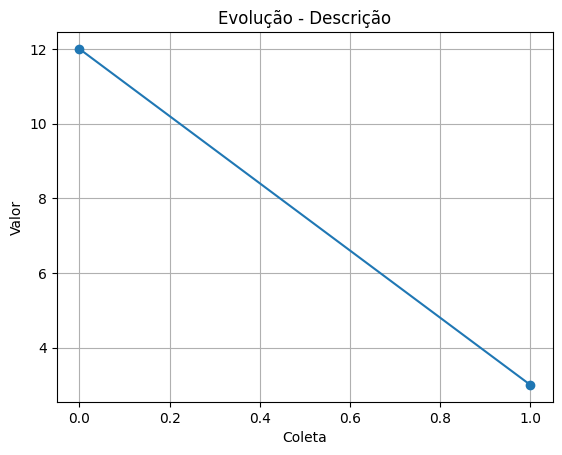

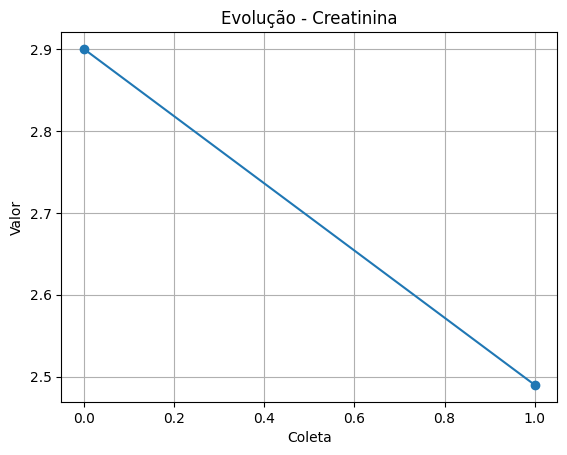

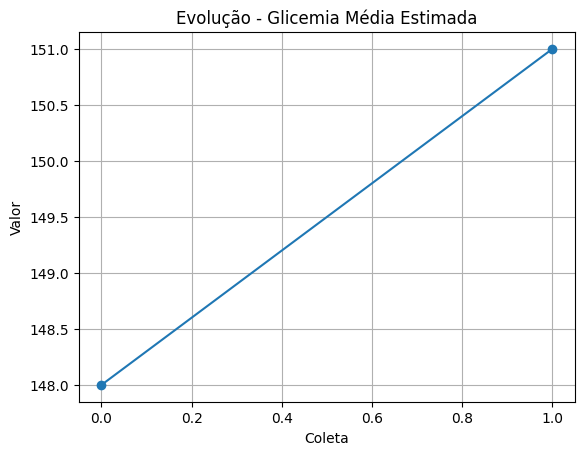

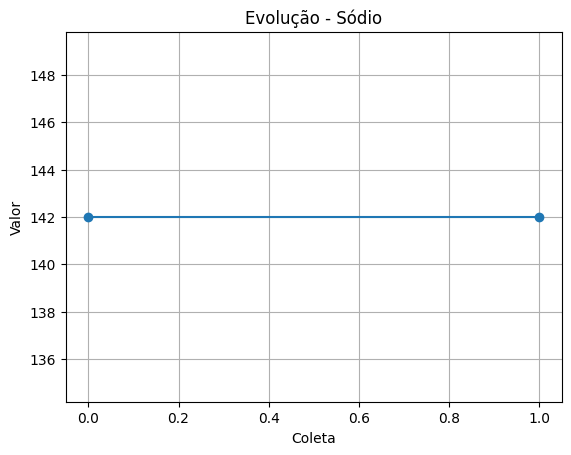

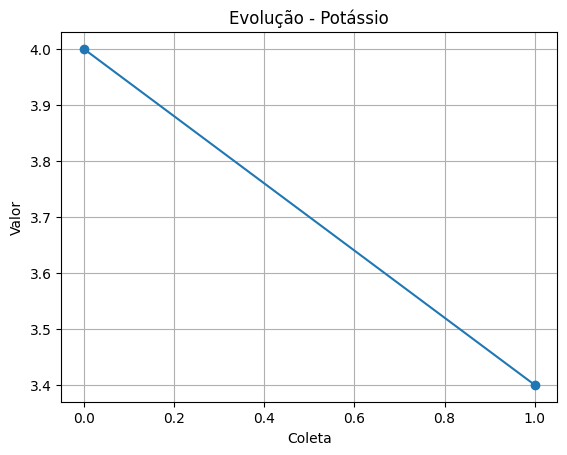

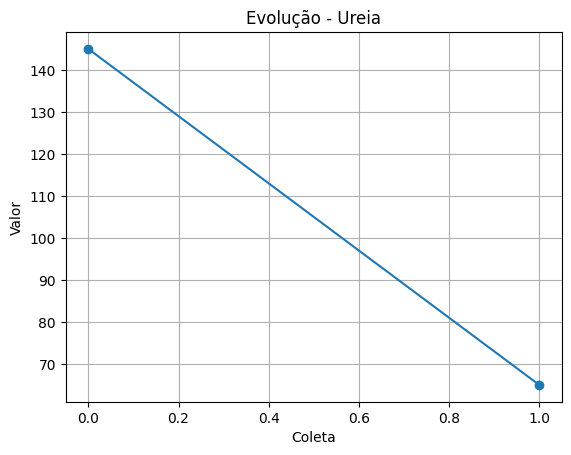

Exames com dados suficientes:
- Descrição
- Creatinina
- Glicemia Média Estimada
- Sódio
- Potássio
- Ureia


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import re

# -------------------------
# FUNÇÃO PRA EXTRAIR NÚMERO
# -------------------------
def extrair_numero(valor):
    if isinstance(valor, str):
        match = re.search(r"[\d,\.]+", valor)
        if match:
            return float(match.group().replace(',', '.'))
    return np.nan

# -------------------------
# COLETAR EXAMES VÁLIDOS
# -------------------------
exames_validos = []

for _, linha in df.iterrows():
    nome = linha['Descrição']

    # pega Resultado + D0..D9
    valores_brutos = [linha['Resultado']] + [linha[col] for col in colunas_datas]

    # converte pra número
    valores = np.array([extrair_numero(v) for v in valores_brutos])

    # remove NaN
    valores_validos = valores[~np.isnan(valores)]

    # 🔥 FILTRO: só exames com pelo menos 2 valores reais
    if len(valores_validos) >= 2:
        exames_validos.append((nome, valores_validos))

# -------------------------
# PLOTAR GRÁFICOS
# -------------------------
for nome, valores in exames_validos:

    # cria eixo X (tempo)
    x = list(range(len(valores)))

    plt.figure()
    plt.plot(x, valores, marker='o')
    plt.title(f'Evolução - {nome}')
    plt.xlabel('Coleta')
    plt.ylabel('Valor')
    plt.grid()

    plt.show()

# -------------------------
# DEBUG (opcional)
# -------------------------
print("Exames com dados suficientes:")
for nome, _ in exames_validos:
    print("-", nome)

In [75]:
import numpy as np
import re
from sklearn.linear_model import LinearRegression

# -------------------------
# FUNÇÃO
# -------------------------
def extrair_numero(valor):
    if isinstance(valor, str):
        match = re.search(r"[\d,\.]+", valor)
        if match:
            return float(match.group().replace(',', '.'))
    return np.nan

# -------------------------
# TREINAR MODELO POR EXAME
# -------------------------
modelos = {}

for _, linha in df.iterrows():
    nome = linha['Descrição']

    valores_brutos = [linha['Resultado']] + [linha[col] for col in colunas_datas]
    valores = np.array([extrair_numero(v) for v in valores_brutos])
    valores = valores[~np.isnan(valores)]

    # 🔥 só treina se tiver pelo menos 2 pontos
    if len(valores) >= 2:

        X = np.arange(len(valores)).reshape(-1, 1)
        y = valores

        modelo = LinearRegression()
        modelo.fit(X, y)

        # prever próximo ponto
        proximo = modelo.predict([[len(valores)]])[0]

        modelos[nome] = {
            "dados": valores,
            "previsao": proximo
        }

# -------------------------
# RESULTADOS
# -------------------------
for nome, info in modelos.items():
    print(f"\n📊 Exame: {nome}")
    print("Valores:", info["dados"])
    print("🔮 Próximo valor previsto:", round(info["previsao"], 2))


📊 Exame: Descrição
Valores: [12.  3.]
🔮 Próximo valor previsto: -6.0

📊 Exame: Creatinina
Valores: [2.9  2.49]
🔮 Próximo valor previsto: 2.08

📊 Exame: Glicemia Média Estimada
Valores: [148. 151.]
🔮 Próximo valor previsto: 154.0

📊 Exame: Sódio
Valores: [142. 142.]
🔮 Próximo valor previsto: 142.0

📊 Exame: Potássio
Valores: [4.  3.4]
🔮 Próximo valor previsto: 2.8

📊 Exame: Ureia
Valores: [145.  65.]
🔮 Próximo valor previsto: -15.0
